# SKKU 2024 Challenge #3: Heisenberg Spin Glass

In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
import scipy
import itertools

In [2]:
## utils.py
np.set_printoptions(linewidth=np.inf, precision=3)

## Part 1

In [55]:
class H_sg():
    def __init__(self, coefficients1, coefficients2, num_qubits=4):
        self.num_qubits = num_qubits
        self.coefficients1 = coefficients1
        self.coefficients2 = coefficients2
        self.Pauli_X = np.array([
            [0,1],
            [1,0]
        ], dtype=np.complex128)
        self.Pauli_Y = np.array([
            [0,-1j],
            [1j,0]
        ], dtype=np.complex128)
        self.Pauli_Z = np.array([
            [1,0],
            [0,-1]
        ], dtype=np.complex128)
        self.I = np.eye(2, dtype=np.complex128)
        self.__reset__()
        self.eigenSpectrum()
    
    def _Kron(self, array):
        """
        Calculate the Kronecker product of a list of array.

        Args:
            tensors : list of np.array.
            [A_0, A_1, A_2, ..., A_N]
        Returns:
            prod: the Kronecker product of the input array.
            A_0 ⊗ A_1 ⊗ A_2 ⊗ ... ⊗ A_N
        """
        prod = np.array(1)
        if len(array) == 0:
            return prod
        else:
            for element in array:
                prod = np.kron(prod, element)
            return prod
    
    def __reset__(self):
        qubit_idx = [idx for idx in range(self.num_qubits)]
        combinations = itertools.combinations(qubit_idx, 2)
        
        H_z = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex128)
        for i in range(self.num_qubits):
            temp = [self.I for _ in range(self.num_qubits)]
            temp[i] = self.Pauli_Z
            #print(self.coefficients2[i], i, temp[::-1])
            H_z += self.coefficients2[i]*self._Kron(temp[::-1])
        
        H_heisenberg = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex128)
        for coefficient, pair_idx in zip(self.coefficients1, combinations):
            #print(coefficient, pair_idx)
            H_heisenberg += coefficient * self._H_ij(pair_idx)
            
        
        self.H_sg = H_heisenberg + H_z
        
    def _H_ij(self, qubit_idx):
        idx_1, idx_2 = list(qubit_idx)
        temp = [self.I for _ in range(self.num_qubits)]
        
        X = temp.copy(); Y = temp.copy(); Z = temp.copy()
        
        X[idx_1] = self.Pauli_X; X[idx_2] = self.Pauli_X
        Y[idx_1] = self.Pauli_Y; Y[idx_2] = self.Pauli_Y
        Z[idx_1] = self.Pauli_Z; Z[idx_2] = self.Pauli_Z
        
        return self._Kron(X[::-1]) + self._Kron(Y[::-1]) + self._Kron(Z[::-1])
    
    def eigenSpectrum(self):
        self.e_val, self.e_vec = np.linalg.eigh(self.H_sg)
        return self.e_val
    
    def plot_eigspectrum(self):
        fig, ax = plt.subplot()
        
        return 0

In [4]:
result = {}
for i in itertools.product([1,-1], repeat=6):
    temp = H_sg(i, [0,0,0,0])
    result[i] = temp.e_val

0 0 [array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])]
0 1 [array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])]
0 2 [array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])]
0 3 [array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])]
0 0 [array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]), array([[1.+0.j, 0.+0.j]

In [5]:
check_same = {}
eig_spectrum = {}
idx = 0
for key, item in result.items():
    isIn = False
    for new_key, new_item in check_same.items():
        if (np.abs(eig_spectrum[new_key] - item) < 1e-8 ).all():
            isIn = True
            check_same[new_key].append(key)
            break
        
    if isIn:
        continue
    else:
        idx += 1
        check_same[idx] = [key]
        eig_spectrum[idx] = item
        

In [6]:
check_same[11]

[(-1, -1, -1, -1, -1, -1)]

In [7]:
eig_spectrum

{1: array([-6., -6., -2., -2., -2., -2., -2., -2., -2., -2., -2.,  6.,  6.,  6.,  6.,  6.]),
 2: array([-8.000e+00, -4.000e+00, -4.000e+00, -4.000e+00, -4.000e+00, -4.000e+00, -4.000e+00,  2.429e-15,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00]),
 3: array([-6., -6., -6., -6., -2., -2., -2.,  2.,  2.,  2.,  2.,  2.,  2.,  6.,  6.,  6.]),
 4: array([-8.000e+00, -8.000e+00, -8.000e+00, -2.445e-15, -4.348e-16,  0.000e+00,  0.000e+00,  0.000e+00,  2.220e-16,  3.494e-15,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00,  4.000e+00]),
 5: array([-4.000e+00, -4.000e+00, -4.000e+00, -4.000e+00, -4.000e+00, -4.000e+00, -2.675e-15, -1.862e-15, -2.520e-17,  0.000e+00,  0.000e+00,  9.342e-17,  2.667e-15,  8.000e+00,  8.000e+00,  8.000e+00]),
 6: array([-10.,  -6.,  -6.,  -6.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   2.,   6.]),
 7: array([-6.928e+00, -5.657e+00, -5.657e+00, -5.657e+00, -1.836e-15, -1.282e-15, -6.943e

In [131]:
class AdiabaticSimulator(H_sg):
    def __init__(self, coefficients1, coefficients2, num_qubits=4) -> None:
        super().__init__(coefficients1, coefficients2, num_qubits)
        
        temp = [self.I for _ in range(self.num_qubits)]
        #temp = [self.Pauli_X for _ in range(self.num_qubits)]
        H_m = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex128)
        for i in range(self.num_qubits):
            temp[i] = self.Pauli_X
            H_m -= self._Kron(temp[::-1])
        self.H_m = H_m
        
    def Propagator(self, s):
        return (1-s)*self.H_m + s*self.H_sg
    
    def EigenSpectrum(self):
        result = np.zeros([16,1000])
        time_step = np.linspace(0,1,1000)
        for i in range(len(time_step)):
            e_val = np.linalg.eigvalsh(self.Propagator(time_step[i]))
            result[:, i] = e_val
            
        return result
    
    def AdiabaticEvolution(self, tau, N):
        time_step = np.linspace(0, tau, N)
        dt = time_step[1] - time_step[0]
        
        ground_state = np.ones(2**self.num_qubits)/np.sqrt(2**self.num_qubits)
        for t in time_step:
            H = self.Propagator(t/tau)
            propagator = scipy.linalg.expm(-1j*dt*H)
            ground_state = propagator @ ground_state
        
        _, e_vec = np.linalg.eigh(self.H_sg)
        
        exact_ground = e_vec[:, 0]
        
        print(exact_ground.conj() * exact_ground)
        #prob = prob.conj() * prob
        
        return ground_state, exact_ground

In [ ]:
test = AdiabaticSimulator([-1,-1,-1,-1,-1,-1],[0,0,0,0])

In [ ]:
result = test.EigenSpectrum()



In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
time_step = np.linspace(0,1,1000)
for i in range(result.shape[0]):
	ax.plot(time_step, result[i,:])


In [134]:
test = AdiabaticSimulator([-1,2,3,-2,-3,-4],[1,-1,2,3],4)

In [63]:
result = test.EigenSpectrum()

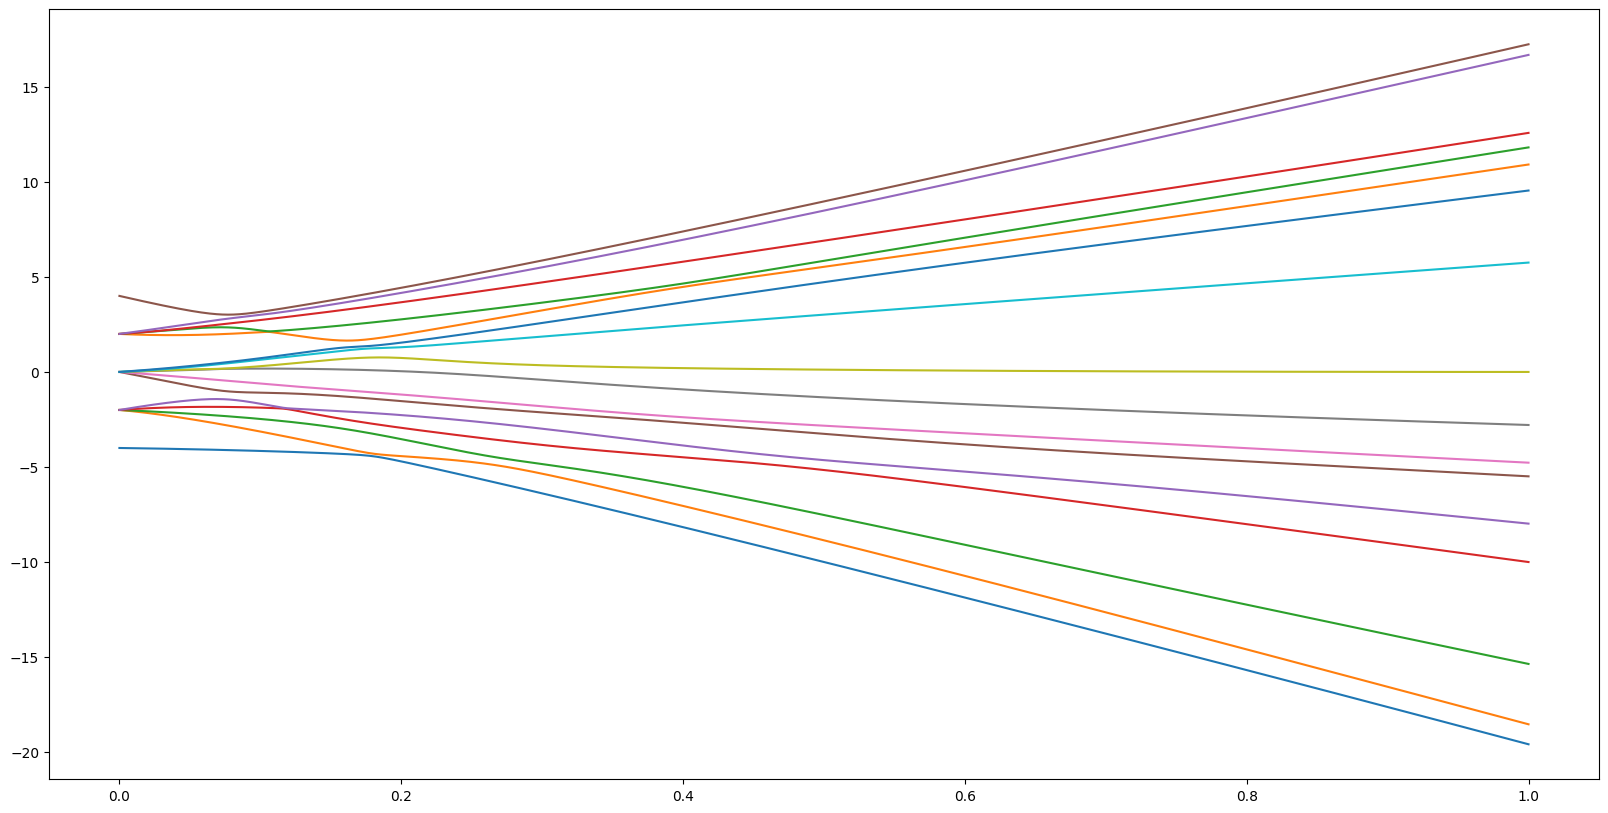

In [21]:
fig, ax = plt.subplots(figsize=(20,10))
time_step = np.linspace(0,1,1000)
for i in range(result.shape[0]):
	ax.plot(time_step, result[i,:])

In [152]:
ground_state, exact_ground = test.AdiabaticEvolution(3000,6000)
(ground_state.conj() * ground_state).real

[0.000e+00+0.j 1.834e-69+0.j 2.665e-66+0.j 2.477e-33+0.j 1.919e-63+0.j 5.926e-34+0.j 8.944e-34+0.j 1.217e-01+0.j 8.890e-64+0.j 8.227e-34+0.j 4.728e-34+0.j 9.449e-02+0.j 1.655e-34+0.j 6.334e-03+0.j 7.775e-01+0.j 0.000e+00+0.j]


array([6.797e-08, 4.798e-08, 6.402e-07, 1.078e-04, 5.752e-08, 1.361e-04, 6.746e-05, 1.216e-01, 1.277e-07, 1.339e-04, 8.467e-05, 9.470e-02, 5.467e-04, 6.228e-03, 7.764e-01, 3.196e-08])

In [ ]:
#(exact_ground.conj() * exact_ground).real

array([6.797e-08, 4.798e-08, 6.402e-07, 1.078e-04, 5.752e-08, 1.361e-04, 6.746e-05, 1.216e-01, 1.277e-07, 1.339e-04, 8.467e-05, 9.470e-02, 5.467e-04, 6.228e-03, 7.764e-01, 3.196e-08])